<a href="https://colab.research.google.com/github/SalmaneSossey/tp5_dl/blob/main/notebooks/TP5_Knowledge_Distillation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# TP5 - Knowledge Distillation

**ENSIAS Deep Learning TP**  
**Topic:** *Knowledge Distillation - De la distillation classique aux methodes avancees*

This notebook is the main deliverable for the TP. It follows the statement in two independent parts:

1. **Part 1:** response-based knowledge distillation on filtered MNIST with a `ResNet-50` teacher, a compact `MicroCNN` student, and an extension with Attention Transfer.
2. **Part 2:** advanced knowledge distillation on filtered CIFAR-10 with a `VGG-16` teacher, a `TinyCNN` student, and a comparison between classical KD, FitNets, and RKD.

The notebook is designed to run in **VS Code** or **Colab** with relative paths only. Long training cells are clearly marked. Figures are saved to `figures/` and tables to `results/`.


## 2. Environment and imports

This notebook is now **standalone**: all helper functions and model definitions are embedded directly in notebook cells so it can run in Google Colab even when only the `.ipynb` file is opened.

For the full official training runs, switch Colab to **GPU** before execution. On CPU, the notebook keeps long experiments disabled by default.


In [2]:
from pathlib import Path
import copy
import itertools
import json
import math
import os
import random
import sys
import time
import warnings
from dataclasses import dataclass
from typing import Callable, Dict, Iterable, Sequence

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display
from sklearn.manifold import TSNE
from sklearn.metrics import precision_score

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as tv_models
from torch.utils.data import DataLoader, Dataset, Subset
from torchvision import datasets, transforms

try:
    import google.colab  # type: ignore
    IN_COLAB = True
except ImportError:
    IN_COLAB = False

ROOT = Path('.').resolve()
DATA_DIR = ROOT / 'data'
FIGURES_DIR = ROOT / 'figures'
RESULTS_DIR = ROOT / 'results'
REPORTS_DIR = ROOT / 'reports'
for folder in (DATA_DIR, FIGURES_DIR, RESULTS_DIR, REPORTS_DIR):
    folder.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid')


## 3. Standalone helper definitions

The support code that previously lived in `src/` is inlined below so the notebook no longer depends on an external folder structure.


In [2]:
# ==== Inlined from utils.py ====

import random
from pathlib import Path
from typing import Dict, Iterable, Sequence

import numpy as np
import pandas as pd
import torch
from torch.utils.data import Dataset

PROJECT_ROOT = ROOT if "ROOT" in globals() else Path.cwd().resolve()
FIGURES_DIR = PROJECT_ROOT / "figures"
RESULTS_DIR = PROJECT_ROOT / "results"
REPORTS_DIR = PROJECT_ROOT / "reports"


def ensure_project_dirs() -> None:
    for folder in (FIGURES_DIR, RESULTS_DIR, REPORTS_DIR):
        folder.mkdir(parents=True, exist_ok=True)


def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False


def get_device() -> torch.device:
    return torch.device("cuda" if torch.cuda.is_available() else "cpu")


def count_params(model: torch.nn.Module, trainable_only: bool = False, verbose: bool = True) -> int:
    parameters = model.parameters()
    if trainable_only:
        parameters = (parameter for parameter in parameters if parameter.requires_grad)
    total = sum(parameter.numel() for parameter in parameters)
    if verbose:
        print(f"{model.__class__.__name__}: {total / 1_000:.2f} K parameters")
    return total


def model_size_kb(model: torch.nn.Module) -> float:
    total_bytes = 0
    for tensor in model.state_dict().values():
        total_bytes += tensor.nelement() * tensor.element_size()
    return total_bytes / 1024.0


def save_dataframe(frame: pd.DataFrame, filename: str) -> Path:
    ensure_project_dirs()
    target = RESULTS_DIR / filename
    frame.to_csv(target, index=False)
    return target


def format_size_kb(size_kb: float) -> str:
    if size_kb >= 1024:
        return f"{size_kb / 1024:.2f} MB"
    return f"{size_kb:.2f} KB"


def extract_targets(dataset) -> list[int]:
    targets = getattr(dataset, "targets", None)
    if targets is None:
        raise AttributeError("Dataset does not expose a `targets` attribute.")
    if isinstance(targets, torch.Tensor):
        return targets.tolist()
    return [int(target) for target in targets]


class LabelMappedSubset(Dataset):
    def __init__(self, dataset, keep_labels: Sequence[int], label_map: Dict[int, int]):
        self.dataset = dataset
        self.keep_labels = set(int(label) for label in keep_labels)
        self.label_map = {int(source): int(target) for source, target in label_map.items()}
        dataset_targets = extract_targets(dataset)
        self.indices = [index for index, label in enumerate(dataset_targets) if int(label) in self.keep_labels]

    def __len__(self) -> int:
        return len(self.indices)

    def __getitem__(self, index: int):
        item, label = self.dataset[self.indices[index]]
        return item, self.label_map[int(label)]


def build_label_filtered_dataset(dataset, keep_labels: Sequence[int], label_map: Dict[int, int]) -> LabelMappedSubset:
    return LabelMappedSubset(dataset=dataset, keep_labels=keep_labels, label_map=label_map)


def select_indices_by_label(dataset, per_label: int, num_classes: int) -> list[int]:
    counts = {label: 0 for label in range(num_classes)}
    selected: list[int] = []
    for index, (_, label) in enumerate(dataset):
        label = int(label)
        if counts[label] >= per_label:
            continue
        counts[label] += 1
        selected.append(index)
        if all(count >= per_label for count in counts.values()):
            break
    return selected


def repeat_channels_if_needed(inputs: torch.Tensor, target_channels: int) -> torch.Tensor:
    if inputs.ndim != 4:
        raise ValueError("Expected a 4D tensor shaped as (batch, channels, height, width).")
    if inputs.size(1) == target_channels:
        return inputs
    if inputs.size(1) == 1 and target_channels == 3:
        return inputs.repeat(1, 3, 1, 1)
    raise ValueError(f"Cannot adapt {inputs.size(1)} input channels to {target_channels}.")


def first_conv_in_channels(model: torch.nn.Module) -> int:
    for module in model.modules():
        if isinstance(module, torch.nn.Conv2d):
            return int(module.in_channels)
    raise ValueError("Model does not contain a Conv2d layer.")


def adapt_inputs_to_model(model: torch.nn.Module, inputs: torch.Tensor) -> torch.Tensor:
    target_channels = first_conv_in_channels(model)
    return repeat_channels_if_needed(inputs, target_channels)


def load_checkpoint_if_available(model: torch.nn.Module, checkpoint_path: str | Path, map_location="cpu") -> bool:
    path = Path(checkpoint_path)
    if not path.exists():
        return False
    state = torch.load(path, map_location=map_location)
    model.load_state_dict(state)
    return True


def save_checkpoint(model: torch.nn.Module, checkpoint_path: str | Path) -> Path:
    path = Path(checkpoint_path)
    path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(model.state_dict(), path)
    return path


def summarize_model_table(rows: Iterable[dict], filename: str | None = None) -> pd.DataFrame:
    frame = pd.DataFrame(list(rows))
    if filename is not None and not frame.empty:
        save_dataframe(frame, filename)
    return frame


# ==== Inlined from models.py ====

from dataclasses import dataclass
from typing import Callable

import torch
import torch.nn as nn
import torchvision.models as tv_models


@dataclass
class ModelLoadResult:
    model: nn.Module
    message: str


class MicroCNN(nn.Module):
    def __init__(self, num_classes: int = 3):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 48, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(48),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(48 * 4 * 4, num_classes)

    def forward_features(self, inputs: torch.Tensor) -> dict[str, torch.Tensor]:
        feature1 = self.block1(inputs)
        feature2 = self.block2(feature1)
        feature3 = self.block3(feature2)
        representation = torch.flatten(feature3, 1)
        return {
            "block1": feature1,
            "block2": feature2,
            "block3": feature3,
            "representation": representation,
        }

    def get_representation(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.forward_features(inputs)["representation"]

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.forward_features(inputs)
        return self.classifier(features["representation"])


class SmallMNISTCNN(nn.Module):
    def __init__(self, num_classes: int = 3):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(8),
            nn.ReLU(inplace=True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(8, 12, kernel_size=3, stride=2, padding=1, bias=False),
            nn.BatchNorm2d(12),
            nn.ReLU(inplace=True),
        )
        self.classifier = nn.Linear(12 * 8 * 8, num_classes)

    def forward_features(self, inputs: torch.Tensor) -> dict[str, torch.Tensor]:
        feature1 = self.block1(inputs)
        feature2 = self.block2(feature1)
        representation = torch.flatten(feature2, 1)
        return {
            "block1": feature1,
            "block2": feature2,
            "representation": representation,
        }

    def get_representation(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.forward_features(inputs)["representation"]

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.forward_features(inputs)
        return self.classifier(features["representation"])


class TinyCNN(nn.Module):
    def __init__(self, num_classes: int = 4):
        super().__init__()
        self.block1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(16),
            nn.ReLU(inplace=True),
        )
        self.block2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
        )
        self.pool1 = nn.MaxPool2d(kernel_size=2)
        self.block3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
        )
        self.block4 = nn.Sequential(
            nn.Conv2d(64, 128, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
        )
        self.pool2 = nn.MaxPool2d(kernel_size=2)
        self.avgpool = nn.AdaptiveAvgPool2d((1, 1))
        self.classifier = nn.Linear(128, num_classes)

    def forward_features(self, inputs: torch.Tensor) -> dict[str, torch.Tensor]:
        feature1 = self.block1(inputs)
        feature2 = self.block2(feature1)
        pooled1 = self.pool1(feature2)
        feature3 = self.block3(pooled1)
        feature4 = self.block4(feature3)
        pooled2 = self.pool2(feature4)
        representation = torch.flatten(self.avgpool(pooled2), 1)
        return {
            "block1": feature1,
            "block2": feature2,
            "pool1": pooled1,
            "block3": feature3,
            "block4": feature4,
            "pool2": pooled2,
            "representation": representation,
        }

    def get_representation(self, inputs: torch.Tensor) -> torch.Tensor:
        return self.forward_features(inputs)["representation"]

    def forward(self, inputs: torch.Tensor) -> torch.Tensor:
        features = self.forward_features(inputs)
        return self.classifier(features["representation"])


def _load_with_fallback(builder: Callable, weights, weight_message: str) -> ModelLoadResult:
    try:
        model = builder(weights=weights)
        return ModelLoadResult(model=model, message=weight_message)
    except Exception as error:  # pragma: no cover - depends on runtime connectivity
        model = builder(weights=None)
        return ModelLoadResult(
            model=model,
            message=f"Fell back to randomly initialized weights because pretrained weights were unavailable: {error}",
        )


def build_resnet50_teacher(num_classes: int = 3) -> ModelLoadResult:
    weights = tv_models.ResNet50_Weights.DEFAULT
    load_result = _load_with_fallback(
        builder=tv_models.resnet50,
        weights=weights,
        weight_message="Loaded ResNet-50 with ImageNet pretrained weights.",
    )
    model = load_result.model
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return ModelLoadResult(model=model, message=load_result.message)


def build_resnet18_student(num_classes: int = 3) -> ModelLoadResult:
    weights = tv_models.ResNet18_Weights.DEFAULT
    load_result = _load_with_fallback(
        builder=tv_models.resnet18,
        weights=weights,
        weight_message="Loaded ResNet-18 with ImageNet pretrained weights.",
    )
    model = load_result.model
    in_features = model.fc.in_features
    model.fc = nn.Linear(in_features, num_classes)
    return ModelLoadResult(model=model, message=load_result.message)


def build_vgg16_teacher(num_classes: int = 4) -> ModelLoadResult:
    weights = tv_models.VGG16_Weights.DEFAULT
    load_result = _load_with_fallback(
        builder=tv_models.vgg16,
        weights=weights,
        weight_message="Loaded VGG-16 with ImageNet pretrained weights.",
    )
    model = load_result.model
    classifier = list(model.classifier.children())
    classifier[-1] = nn.Linear(classifier[-1].in_features, num_classes)
    model.classifier = nn.Sequential(*classifier)
    return ModelLoadResult(model=model, message=load_result.message)


# ==== Inlined from kd_losses.py ====

import itertools
import random

import torch
import torch.nn.functional as F


def kd_loss(
    student_logits: torch.Tensor,
    teacher_logits: torch.Tensor,
    true_labels: torch.Tensor,
    T: float,
    alpha: float,
) -> torch.Tensor:
    hard_loss = F.cross_entropy(student_logits, true_labels)
    teacher_probs = F.softmax(teacher_logits / T, dim=1)
    student_log_probs = F.log_softmax(student_logits / T, dim=1)
    # A class-wise mean keeps the loss scale stable for small classification heads.
    soft_loss = -(teacher_probs * student_log_probs).mean(dim=1).mean()
    return alpha * hard_loss + (1.0 - alpha) * soft_loss


def attention_map(feature_map: torch.Tensor) -> torch.Tensor:
    attention = feature_map.pow(2).mean(dim=1)
    flattened = attention.flatten(1)
    normalized = F.normalize(flattened, p=2, dim=1)
    return normalized.view_as(attention)


def at_loss(student_features: torch.Tensor, teacher_features: torch.Tensor, beta: float = 0.1) -> torch.Tensor:
    student_attention = attention_map(student_features)
    teacher_attention = attention_map(teacher_features.detach())
    if student_attention.shape[-2:] != teacher_attention.shape[-2:]:
        teacher_attention = F.interpolate(
            teacher_attention.unsqueeze(1),
            size=student_attention.shape[-2:],
            mode="bilinear",
            align_corners=False,
        ).squeeze(1)
    return beta * F.mse_loss(student_attention, teacher_attention)


def fitnets_loss(
    student_feat: torch.Tensor,
    teacher_feat: torch.Tensor,
    adapter: torch.nn.Module,
    gamma: float,
    kd_loss_val: torch.Tensor,
) -> torch.Tensor:
    adapted_student = adapter(student_feat)
    teacher_target = teacher_feat.detach()
    if adapted_student.shape[-2:] != teacher_target.shape[-2:]:
        adapted_student = F.interpolate(
            adapted_student,
            size=teacher_target.shape[-2:],
            mode="bilinear",
            align_corners=False,
        )
    hint_loss = F.mse_loss(adapted_student, teacher_target)
    return kd_loss_val + gamma * hint_loss


def _pairwise_euclidean(features: torch.Tensor) -> torch.Tensor:
    return torch.cdist(features, features, p=2)


def rkd_distance_loss(feat_T: torch.Tensor, feat_S: torch.Tensor) -> torch.Tensor:
    teacher = feat_T.detach().flatten(1)
    student = feat_S.flatten(1)
    with torch.no_grad():
        teacher_dist = _pairwise_euclidean(teacher)
        teacher_dist = teacher_dist / teacher_dist[teacher_dist > 0].mean().clamp_min(1e-8)
    student_dist = _pairwise_euclidean(student)
    student_dist = student_dist / student_dist[student_dist > 0].mean().clamp_min(1e-8)
    return F.smooth_l1_loss(student_dist, teacher_dist)


def rkd_angle_loss(feat_T: torch.Tensor, feat_S: torch.Tensor, triplets: int = 64) -> torch.Tensor:
    teacher = feat_T.detach().flatten(1)
    student = feat_S.flatten(1)
    batch_size = teacher.size(0)
    if batch_size < 3:
        return torch.zeros((), device=teacher.device)

    all_triplets = list(itertools.combinations(range(batch_size), 3))
    sampled_triplets = random.sample(all_triplets, k=min(triplets, len(all_triplets)))
    teacher_angles = []
    student_angles = []
    for i, j, k in sampled_triplets:
        teacher_ij = F.normalize(teacher[i] - teacher[j], dim=0)
        teacher_ik = F.normalize(teacher[i] - teacher[k], dim=0)
        student_ij = F.normalize(student[i] - student[j], dim=0)
        student_ik = F.normalize(student[i] - student[k], dim=0)
        teacher_angles.append(torch.sum(teacher_ij * teacher_ik))
        student_angles.append(torch.sum(student_ij * student_ik))
    teacher_tensor = torch.stack(teacher_angles)
    student_tensor = torch.stack(student_angles)
    return F.smooth_l1_loss(student_tensor, teacher_tensor)


# ==== Inlined from train_utils.py ====

from dataclasses import dataclass
from typing import Callable

import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader



@dataclass
class HistoryEntry:
    epoch: int
    train_loss: float
    train_acc: float
    test_loss: float
    test_acc: float


class FeatureHook:
    def __init__(self, module: nn.Module):
        self.output = None
        self.handle = module.register_forward_hook(self._hook)

    def _hook(self, module, inputs, output):
        self.output = output

    def close(self) -> None:
        self.handle.remove()


def _batch_accuracy(logits: torch.Tensor, labels: torch.Tensor) -> float:
    predictions = logits.argmax(dim=1)
    return (predictions == labels).float().mean().item()


def train_supervised_epoch(
    model: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
) -> dict[str, float]:
    model.train()
    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()
        adapted_inputs = adapt_inputs_to_model(model, inputs)
        logits = model(adapted_inputs)
        loss = F.cross_entropy(logits, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        running_acc += _batch_accuracy(logits, labels)
        total_batches += 1
    return {
        "loss": running_loss / max(total_batches, 1),
        "acc": running_acc / max(total_batches, 1),
    }


def train_epoch(
    student: nn.Module,
    teacher: nn.Module,
    loader: DataLoader,
    optimizer: torch.optim.Optimizer,
    device: torch.device,
    T: float,
    alpha: float,
    extra_loss_fn: Callable[[torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor] | None = None,
) -> dict[str, float]:
    student.train()
    teacher.eval()
    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0

    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        optimizer.zero_grad()

        student_inputs = adapt_inputs_to_model(student, inputs)
        student_logits = student(student_inputs)

        with torch.no_grad():
            teacher_inputs = adapt_inputs_to_model(teacher, inputs)
            teacher_logits = teacher(teacher_inputs)

        loss = kd_loss(student_logits, teacher_logits, labels, T=T, alpha=alpha)
        if extra_loss_fn is not None:
            loss = extra_loss_fn(loss, student_logits, teacher_logits)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        running_acc += _batch_accuracy(student_logits, labels)
        total_batches += 1

    return {
        "loss": running_loss / max(total_batches, 1),
        "acc": running_acc / max(total_batches, 1),
    }


@torch.no_grad()
def evaluate(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
) -> dict[str, float]:
    model.eval()
    running_loss = 0.0
    running_acc = 0.0
    total_batches = 0
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        adapted_inputs = adapt_inputs_to_model(model, inputs)
        logits = model(adapted_inputs)
        running_loss += F.cross_entropy(logits, labels).item()
        running_acc += _batch_accuracy(logits, labels)
        total_batches += 1
    return {
        "loss": running_loss / max(total_batches, 1),
        "acc": running_acc / max(total_batches, 1),
    }


def fit_model(
    student: nn.Module,
    train_loader: DataLoader,
    test_loader: DataLoader,
    device: torch.device,
    epochs: int,
    optimizer: torch.optim.Optimizer,
    teacher: nn.Module | None = None,
    T: float = 1.0,
    alpha: float = 1.0,
    extra_loss_fn: Callable[[torch.Tensor, torch.Tensor, torch.Tensor], torch.Tensor] | None = None,
) -> pd.DataFrame:
    history: list[HistoryEntry] = []
    for epoch in range(1, epochs + 1):
        if teacher is None:
            train_metrics = train_supervised_epoch(student, train_loader, optimizer, device)
        else:
            train_metrics = train_epoch(
                student=student,
                teacher=teacher,
                loader=train_loader,
                optimizer=optimizer,
                device=device,
                T=T,
                alpha=alpha,
                extra_loss_fn=extra_loss_fn,
            )
        test_metrics = evaluate(student, test_loader, device)
        history.append(
            HistoryEntry(
                epoch=epoch,
                train_loss=train_metrics["loss"],
                train_acc=train_metrics["acc"],
                test_loss=test_metrics["loss"],
                test_acc=test_metrics["acc"],
            )
        )
    return pd.DataFrame(history)


@torch.no_grad()
def collect_representations(
    model: nn.Module,
    loader: DataLoader,
    device: torch.device,
    representation_fn: Callable[[nn.Module, torch.Tensor], torch.Tensor],
    max_items: int | None = None,
) -> tuple[torch.Tensor, torch.Tensor]:
    model.eval()
    features = []
    labels = []
    collected = 0
    for inputs, batch_labels in loader:
        inputs = inputs.to(device)
        batch_labels = batch_labels.to(device)
        adapted_inputs = adapt_inputs_to_model(model, inputs)
        representations = representation_fn(model, adapted_inputs)
        features.append(representations.detach().cpu())
        labels.append(batch_labels.detach().cpu())
        collected += batch_labels.size(0)
        if max_items is not None and collected >= max_items:
            break
    feature_tensor = torch.cat(features, dim=0)
    label_tensor = torch.cat(labels, dim=0)
    if max_items is not None:
        feature_tensor = feature_tensor[:max_items]
        label_tensor = label_tensor[:max_items]
    return feature_tensor, label_tensor


# ==== Inlined from metrics.py ====

import time

import numpy as np
import torch
import torch.nn.functional as F



@torch.no_grad()
def measure_latency(
    model: torch.nn.Module,
    input_shape: tuple[int, int, int, int],
    device: torch.device,
    n: int = 100,
    warmup: int = 10,
) -> float:
    model.eval()
    sample = torch.randn(*input_shape, device=device)
    sample = adapt_inputs_to_model(model, sample)
    for _ in range(warmup):
        _ = model(sample)
    if device.type == "cuda":
        torch.cuda.synchronize()
    start = time.perf_counter()
    for _ in range(n):
        _ = model(sample)
    if device.type == "cuda":
        torch.cuda.synchronize()
    elapsed = time.perf_counter() - start
    return (elapsed / n) * 1000.0


def cosine_similarity_matrix(prototypes: torch.Tensor) -> np.ndarray:
    normalized = F.normalize(prototypes, dim=1)
    return (normalized @ normalized.T).cpu().numpy()


def class_prototypes(features: torch.Tensor, labels: torch.Tensor, num_classes: int) -> torch.Tensor:
    prototypes = []
    for class_index in range(num_classes):
        class_features = features[labels == class_index]
        prototypes.append(class_features.mean(dim=0))
    return torch.stack(prototypes)


# ==== Inlined from visualization.py ====

from pathlib import Path
from typing import Sequence

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns


sns.set_theme(style="whitegrid")


def _finalize_figure(fig: plt.Figure, filename: str | None = None) -> Path | None:
    ensure_project_dirs()
    if filename is None:
        return None
    path = FIGURES_DIR / filename
    fig.savefig(path, bbox_inches="tight", dpi=180)
    return path


def plot_soft_label_bars(
    images: np.ndarray,
    probs_t1: np.ndarray,
    probs_t4: np.ndarray,
    class_names: Sequence[str],
    title: str,
    filename: str | None = None,
):
    rows = len(images)
    fig, axes = plt.subplots(rows, 3, figsize=(12, 3 * rows))
    if rows == 1:
        axes = np.expand_dims(axes, axis=0)
    for row in range(rows):
        axes[row, 0].imshow(images[row], cmap="gray")
        axes[row, 0].set_title("Digit image")
        axes[row, 0].axis("off")
        axes[row, 1].bar(class_names, probs_t1[row], color="#457b9d")
        axes[row, 1].set_ylim(0, 1)
        axes[row, 1].set_title("Teacher probs, T=1")
        axes[row, 2].bar(class_names, probs_t4[row], color="#e76f51")
        axes[row, 2].set_ylim(0, 1)
        axes[row, 2].set_title("Teacher probs, T=4")
    fig.suptitle(title, fontsize=14)
    fig.tight_layout()
    _finalize_figure(fig, filename)
    return fig


def plot_history_curves(history_frames: dict[str, object], filename: str | None = None):
    fig, ax = plt.subplots(figsize=(8, 5))
    for label, frame in history_frames.items():
        ax.plot(frame["epoch"], frame["test_acc"], marker="o", linewidth=2, label=label)
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Test accuracy")
    ax.set_title("Validation/Test Accuracy Curves")
    ax.legend()
    fig.tight_layout()
    _finalize_figure(fig, filename)
    return fig


def plot_temperature_curve(frame, filename: str | None = None):
    fig, ax = plt.subplots(figsize=(7, 4.5))
    ax.plot(frame["temperature"], frame["test_acc"], marker="o", linewidth=2, color="#1d3557")
    ax.set_xlabel("Temperature T")
    ax.set_ylabel("Test accuracy")
    ax.set_title("Effect of temperature on KD accuracy")
    fig.tight_layout()
    _finalize_figure(fig, filename)
    return fig


def plot_heatmap_grid(
    heatmaps: Sequence[np.ndarray],
    titles: Sequence[str],
    cmap: str = "magma",
    filename: str | None = None,
    annot: bool = False,
):
    columns = len(heatmaps)
    fig, axes = plt.subplots(1, columns, figsize=(4 * columns, 4))
    if columns == 1:
        axes = [axes]
    for axis, heatmap, title in zip(axes, heatmaps, titles):
        sns.heatmap(heatmap, ax=axis, cmap=cmap, annot=annot, cbar=True, square=True)
        axis.set_title(title)
    fig.tight_layout()
    _finalize_figure(fig, filename)
    return fig


def plot_attention_maps(
    image: np.ndarray,
    teacher_map: np.ndarray,
    student_before: np.ndarray,
    student_after: np.ndarray,
    filename: str | None = None,
):
    fig, axes = plt.subplots(1, 4, figsize=(14, 4))
    axes[0].imshow(image, cmap="gray")
    axes[0].set_title("Input")
    axes[0].axis("off")
    for axis, heatmap, title in zip(
        axes[1:],
        [teacher_map, student_before, student_after],
        ["Teacher", "Student before", "Student after"],
    ):
        axis.imshow(heatmap, cmap="inferno")
        axis.set_title(title)
        axis.axis("off")
    fig.tight_layout()
    _finalize_figure(fig, filename)
    return fig


def plot_tsne_triptych(embeddings: dict[str, np.ndarray], labels: np.ndarray, class_names: Sequence[str], filename: str | None = None):
    fig, axes = plt.subplots(1, len(embeddings), figsize=(5 * len(embeddings), 4))
    if len(embeddings) == 1:
        axes = [axes]
    palette = sns.color_palette("deep", n_colors=len(class_names))
    for axis, (title, points) in zip(axes, embeddings.items()):
        for class_index, class_name in enumerate(class_names):
            mask = labels == class_index
            axis.scatter(points[mask, 0], points[mask, 1], s=28, alpha=0.8, color=palette[class_index], label=class_name)
        axis.set_title(title)
    axes[0].legend()
    fig.tight_layout()
    _finalize_figure(fig, filename)
    return fig


## 4. Reproducibility and device setup

The TP fixes the main reproducibility settings before any dataset or model is created.

- On **CPU**, the notebook keeps long training runs disabled by default.
- On a **CUDA GPU runtime** such as Google Colab with GPU enabled, the notebook automatically enables teacher training and the full experiment suite.

You can still override the flags manually in the next cell if you want a faster debug pass or a full official run.


In [3]:
SEED = 42
seed_everything(SEED)
device = get_device()

USE_ACCELERATED_RUNTIME = device.type == "cuda"
RUN_LONG_EXPERIMENTS = USE_ACCELERATED_RUNTIME
TRAIN_TEACHERS = USE_ACCELERATED_RUNTIME
SAVE_INTERMEDIATE_CHECKPOINTS = True
NUM_WORKERS = 2 if USE_ACCELERATED_RUNTIME else 0
PIN_MEMORY = USE_ACCELERATED_RUNTIME

num_classes = 3
batch_size = 32

if IN_COLAB and device.type != "cuda":
    print("Colab detected but CUDA is not active. For full training runs, switch Runtime > Change runtime type > GPU.")
elif device.type == "cuda":
    print("CUDA runtime detected. Full teacher training and long experiments are enabled by default.")
else:
    print("CPU runtime detected. Long experiments stay disabled by default to avoid very slow execution.")

pd.DataFrame(
    {
        "setting": [
            "seed",
            "device",
            "IN_COLAB",
            "RUN_LONG_EXPERIMENTS",
            "TRAIN_TEACHERS",
            "SAVE_INTERMEDIATE_CHECKPOINTS",
            "NUM_WORKERS",
            "PIN_MEMORY",
            "num_classes",
            "batch_size",
        ],
        "value": [
            SEED,
            str(device),
            IN_COLAB,
            RUN_LONG_EXPERIMENTS,
            TRAIN_TEACHERS,
            SAVE_INTERMEDIATE_CHECKPOINTS,
            NUM_WORKERS,
            PIN_MEMORY,
            num_classes,
            batch_size,
        ],
    }
)


CUDA runtime detected. Full teacher training and long experiments are enabled by default.


,setting,value
0,seed,42
1,device,cuda
2,IN_COLAB,True
3,RUN_LONG_EXPERIMENTS,True
4,TRAIN_TEACHERS,True
5,SAVE_INTERMEDIATE_CHECKPOINTS,True
6,NUM_WORKERS,2
7,PIN_MEMORY,True
8,num_classes,3
9,batch_size,32


# 4. Part 1 - MNIST Response-Based KD

This part follows the statement exactly:

- dataset: `torchvision.datasets.MNIST`
- kept digits: `0`, `1`, `8`
- remapping: `0 -> 0`, `1 -> 1`, `8 -> 2`
- resize: `32 x 32`
- normalization: mean `0.5`, std `0.5`
- batch size: `32`
- teacher: pretrained `ResNet-50` with a 3-class head
- student: `MicroCNN` with exactly three `Conv -> BN -> ReLU` blocks and one fully connected classifier


### P1.1 and P1.2 - Dataset loading

The MNIST pipeline keeps a single grayscale channel for the student. The teacher still uses an ImageNet `ResNet-50`, so the notebook adapts the input to three channels only at model-forward time when needed. This keeps the data pipeline simple and respects the normalization requested in the statement.


In [4]:
mnist_transform = transforms.Compose(
    [
        transforms.Resize((32, 32)),
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,)),
    ]
)

mnist_train_full = datasets.MNIST(root=DATA_DIR, train=True, download=True, transform=mnist_transform)
mnist_test_full = datasets.MNIST(root=DATA_DIR, train=False, download=True, transform=mnist_transform)

mnist_keep = [0, 1, 8]
mnist_label_map = {0: 0, 1: 1, 8: 2}
mnist_class_names = ["0", "1", "8"]

mnist_train = build_label_filtered_dataset(mnist_train_full, keep_labels=mnist_keep, label_map=mnist_label_map)
mnist_test = build_label_filtered_dataset(mnist_test_full, keep_labels=mnist_keep, label_map=mnist_label_map)

mnist_train_loader = DataLoader(mnist_train, batch_size=batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
mnist_test_loader = DataLoader(mnist_test, batch_size=batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

mnist_counts = pd.DataFrame(
    {
        "split": ["train"] * len(mnist_train) + ["test"] * len(mnist_test),
        "label": [label for _, label in mnist_train] + [label for _, label in mnist_test],
    }
).groupby(["split", "label"]).size().reset_index(name="count")
mnist_counts["class_name"] = mnist_counts["label"].map(dict(enumerate(mnist_class_names)))
mnist_counts


100%|██████████| 9.91M/9.91M [00:01<00:00, 6.02MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 162kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.48MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 6.91MB/s]


,split,label,count,class_name
0,test,0,980,0
1,test,1,1135,1
2,test,2,974,8
3,train,0,5923,0
4,train,1,6742,1
5,train,2,5851,8


### P1.3 - Models and teacher preparation

The teacher is built from torchvision `ResNet-50` weights and then its classification head is replaced with `3` outputs. Distillation requires a trained teacher on the filtered MNIST task, so the notebook first tries to load a checkpoint from `results/`. If none exists, the long training cell below can be enabled.

The `MicroCNN` student has exactly three `Conv -> BN -> ReLU` blocks and stays under `100,000` parameters.


In [5]:
mnist_teacher_bundle = build_resnet50_teacher(num_classes=num_classes)
mnist_teacher = mnist_teacher_bundle.model.to(device)
mnist_teacher_ckpt = RESULTS_DIR / "mnist_teacher_resnet50.pt"
mnist_teacher_ready = load_checkpoint_if_available(mnist_teacher, mnist_teacher_ckpt, map_location=device)
mnist_teacher.eval()

micro_student_template = MicroCNN(num_classes=num_classes).to(device)
small_student_template = SmallMNISTCNN(num_classes=num_classes).to(device)
large_student_template = build_resnet18_student(num_classes=num_classes).model.to(device)

assert count_params(micro_student_template, verbose=False) < 100_000, "MicroCNN exceeds 100k parameters."
assert count_params(small_student_template, verbose=False) < 10_000, "Small student exceeds 10k parameters."

print(mnist_teacher_bundle.message)
print(f"Teacher checkpoint found: {mnist_teacher_ready}")
print(f"MicroCNN parameters: {count_params(micro_student_template, verbose=False)}")
print(f"Small student parameters: {count_params(small_student_template, verbose=False)}")


Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 186MB/s]


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 192MB/s]


Loaded ResNet-50 with ImageNet pretrained weights.
Teacher checkpoint found: False
MicroCNN parameters: 21075
Small student parameters: 3283


### Long-run cell - optional MNIST teacher fine-tuning

This cell is intentionally separated because distillation should not start from a random teacher head. If `TRAIN_TEACHERS = False`, the notebook only prepares the function and prints a reminder.


In [6]:
def train_mnist_teacher(epochs: int = 5, lr: float = 1e-4):
    teacher_result = build_resnet50_teacher(num_classes=num_classes)
    teacher_model = teacher_result.model.to(device)
    optimizer = optim.Adam(teacher_model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = train_supervised_epoch(teacher_model, mnist_train_loader, optimizer, device)
        test_metrics = evaluate(teacher_model, mnist_test_loader, device)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_acc": train_metrics["acc"],
                "test_loss": test_metrics["loss"],
                "test_acc": test_metrics["acc"],
            }
        )
        print(f"[MNIST teacher] epoch={epoch:02d} train_acc={train_metrics['acc']:.4f} test_acc={test_metrics['acc']:.4f}")
    history_df = pd.DataFrame(history)
    if SAVE_INTERMEDIATE_CHECKPOINTS:
        save_checkpoint(teacher_model, mnist_teacher_ckpt)
    teacher_model.eval()
    return teacher_model, history_df

if mnist_teacher_ready:
    print(f"Loaded MNIST teacher checkpoint from {mnist_teacher_ckpt}.")
elif TRAIN_TEACHERS:
    mnist_teacher, mnist_teacher_history = train_mnist_teacher()
    mnist_teacher_ready = True
    mnist_teacher.eval()
    display(mnist_teacher_history.tail())
else:
    print("No MNIST teacher checkpoint found. Set TRAIN_TEACHERS=True to fine-tune the teacher before KD experiments.")


[MNIST teacher] epoch=01 train_acc=0.9356 test_acc=0.9984
[MNIST teacher] epoch=02 train_acc=0.9934 test_acc=0.9965
[MNIST teacher] epoch=03 train_acc=0.9969 test_acc=0.9977
[MNIST teacher] epoch=04 train_acc=0.9979 test_acc=0.9984
[MNIST teacher] epoch=05 train_acc=0.9970 test_acc=0.9984


,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.198601,0.935557,0.009508,0.998389
1,2,0.022684,0.993361,0.012677,0.996456
2,3,0.010687,0.996870,0.009741,0.997745
3,4,0.010395,0.997917,0.005946,0.998389
4,5,0.010571,0.997032,0.004998,0.998389


### P1.4 - Model statistics

The TP asks for the number of parameters and the approximate model size. The helper functions `count_params(model)` and `model_size_kb(model)` are reused here for both teacher and student models.


In [7]:
part1_model_stats = summarize_model_table(
    [
        {
            "model": "Teacher - ResNet50",
            "params": count_params(mnist_teacher, verbose=False),
            "params_k": count_params(mnist_teacher, verbose=False) / 1_000,
            "approx_size_kb": model_size_kb(mnist_teacher),
            "approx_size": format_size_kb(model_size_kb(mnist_teacher)),
        },
        {
            "model": "Student - MicroCNN",
            "params": count_params(micro_student_template, verbose=False),
            "params_k": count_params(micro_student_template, verbose=False) / 1_000,
            "approx_size_kb": model_size_kb(micro_student_template),
            "approx_size": format_size_kb(model_size_kb(micro_student_template)),
        },
    ],
    filename="part1_model_stats.csv",
)
part1_model_stats


,model,params,params_k,approx_size_kb,approx_size
0,Teacher - ResNet50,23514179,23514.179,92060.175781,89.90 MB
1,Student - MicroCNN,21075,21.075,83.097656,83.10 KB


### P1.5 - Soft-label visualization on ambiguous digit 8 samples

The goal is to inspect whether temperature reveals teacher hesitation between the remapped classes `0` and `8`. The cell below selects five digit-`8` samples with the smallest teacher margin between class `8` and class `0`, then plots teacher probabilities for `T=1` and `T=4`.

If no trained teacher is available yet, the cell exits cleanly instead of inventing observations.


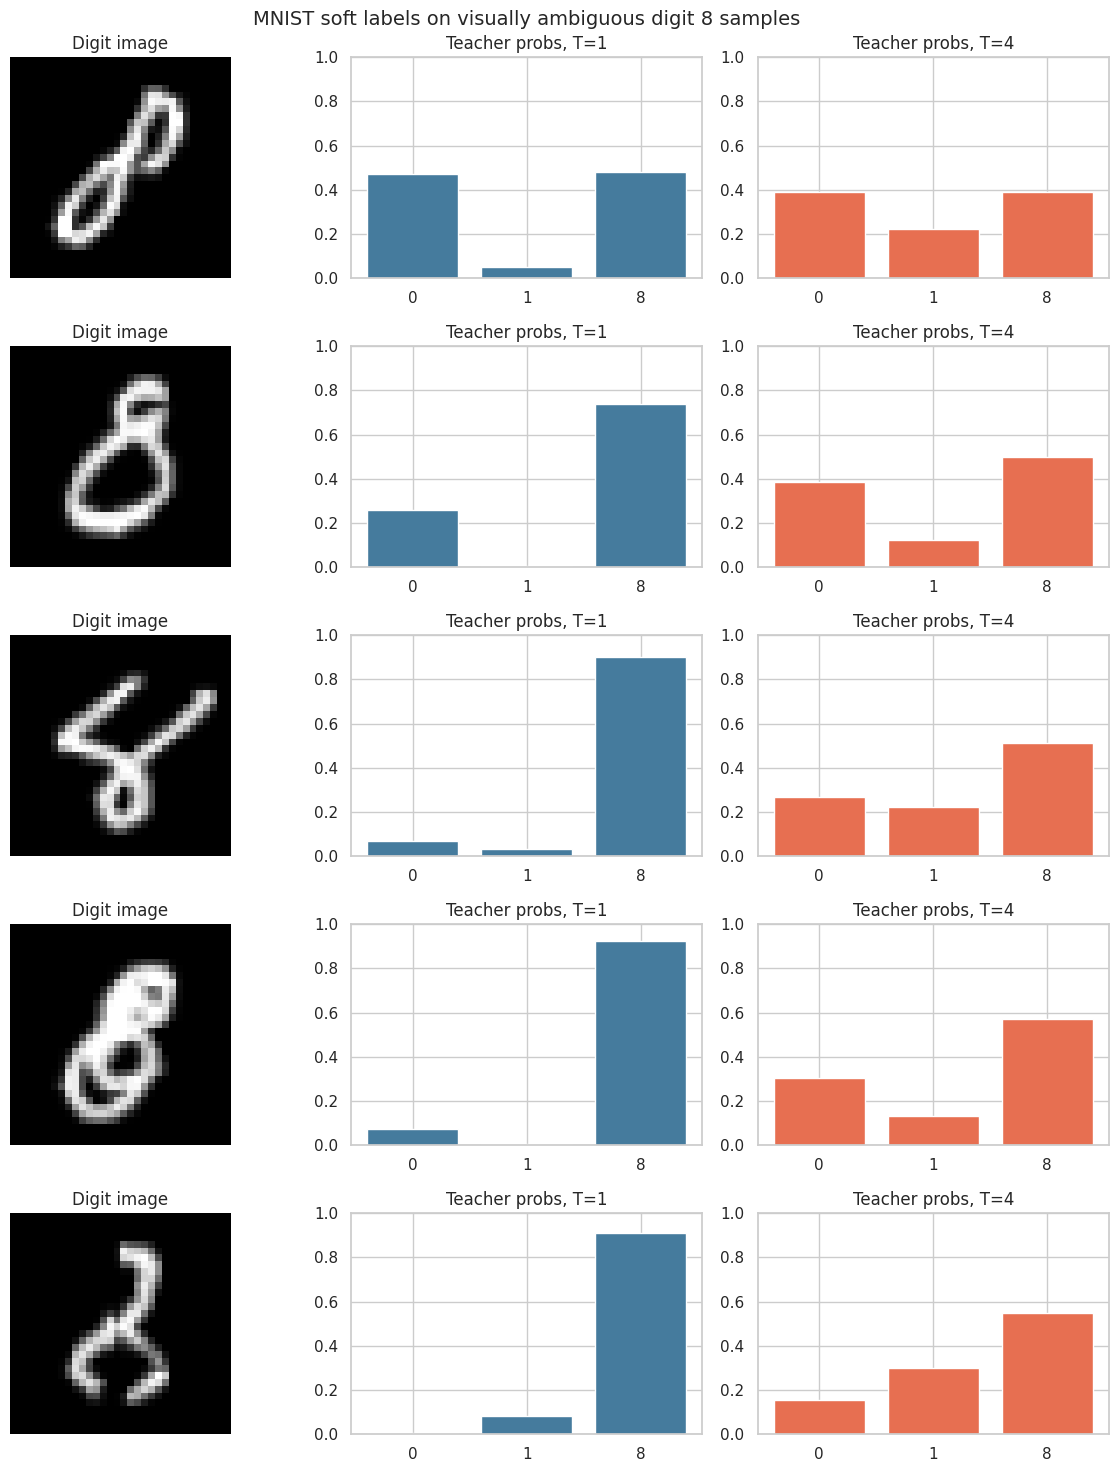

In [8]:
@torch.no_grad()
def teacher_probabilities(model, image_tensor, T: float = 1.0):
    logits = model(adapt_inputs_to_model(model, image_tensor.unsqueeze(0).to(device)))
    return torch.softmax(logits / T, dim=1).squeeze(0).cpu()

@torch.no_grad()
def select_ambiguous_digit_eights(model, dataset, top_k: int = 5):
    scored = []
    for index, (image, label) in enumerate(dataset):
        if label != 2:
            continue
        probs = teacher_probabilities(model, image, T=1.0)
        margin = float(abs(probs[2] - probs[0]))
        scored.append((margin, index, image.cpu(), probs))
    scored.sort(key=lambda item: item[0])
    return scored[:top_k]

if mnist_teacher_ready:
    ambiguous_eights = select_ambiguous_digit_eights(mnist_teacher, mnist_test, top_k=5)
    amb_images = np.stack([item[2].squeeze(0).numpy() for item in ambiguous_eights])
    amb_probs_t1 = np.stack([teacher_probabilities(mnist_teacher, item[2], T=1.0).numpy() for item in ambiguous_eights])
    amb_probs_t4 = np.stack([teacher_probabilities(mnist_teacher, item[2], T=4.0).numpy() for item in ambiguous_eights])
    plot_soft_label_bars(
        amb_images,
        amb_probs_t1,
        amb_probs_t4,
        class_names=mnist_class_names,
        title="MNIST soft labels on visually ambiguous digit 8 samples",
        filename="part1_soft_labels_ambiguous_8.png",
    )
    plt.show()
else:
    print("Soft-label visualization is pending because the MNIST teacher checkpoint is not available yet.")


When the previous figure is executed with a trained teacher, the expected qualitative check is simple: **if `T=4` makes the bar chart flatter than `T=1`, then teacher uncertainty becomes more visible**. Keep the final written observation tied to the actual plots shown above rather than to a guessed outcome.


### P1.6 - Manual KD loss verification

For the toy logits

- `zT = [1.2, 0.5, 4.1]`
- `zS = [0.9, 0.4, 3.6]`
- `y = 2`
- `T = 4`
- `alpha = 0.4`

we use the notebook convention implemented in `src.kd_losses.kd_loss`:

\[
\mathcal{L}_{KD} = lpha \cdot CE(z_S, y) + (1-lpha) \cdot \left[-
rac{1}{C}\sum_{c=1}^{C} p_T^{(c)}(T) \log p_S^{(c)}(T)
ight]
\]

with `C = 3` classes. Using rounded softened probabilities

- `pT(T=4) pprox [0.26, 0.21, 0.53]`
- `pS(T=4) pprox [0.26, 0.23, 0.51]`

and `CE(zS, y) pprox 0.103`, the class-mean soft term is about `0.32`, hence

\[
\mathcal{L}_{KD} pprox 0.4 	imes 0.103 + 0.6 	imes 0.32 pprox 0.23
\]

The tensor implementation below computes the exact value from the logits without manual rounding.


In [9]:
toy_teacher = torch.tensor([[1.2, 0.5, 4.1]], dtype=torch.float32)
toy_student = torch.tensor([[0.9, 0.4, 3.6]], dtype=torch.float32)
toy_labels = torch.tensor([2])
manual_kd_value = kd_loss(toy_student, toy_teacher, toy_labels, T=4.0, alpha=0.4)
print(f"Exact kd_loss value from the implementation: {manual_kd_value.item():.6f}")


Exact kd_loss value from the implementation: 0.244426


### P1.7 - Training and evaluation loop

The reusable training loop is implemented in `src.train_utils`:

- `train_epoch(student, teacher, loader, optimizer, T, alpha)` for response-based KD
- `evaluate(model, loader)` for supervised evaluation

The teacher forward pass is already wrapped in `torch.no_grad()` inside the helper.


In [10]:
part1_runs = {}

@torch.no_grad()
def evaluate_macro_precision(model, loader):
    model.eval()
    predictions = []
    targets = []
    for inputs, labels in loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        logits = model(adapt_inputs_to_model(model, inputs))
        predictions.extend(logits.argmax(dim=1).cpu().tolist())
        targets.extend(labels.cpu().tolist())
    return precision_score(targets, predictions, average="macro", zero_division=0)


def deployment_flag(size_kb: float, latency_ms: float, accuracy: float, size_limit_kb: float, latency_limit_ms: float) -> str:
    if np.isnan(accuracy):
        return "Pending run"
    return "Yes" if size_kb <= size_limit_kb and latency_ms <= latency_limit_ms else "No"


def run_experiment(T: float, alpha: float, label: str, epochs: int):
    student = MicroCNN(num_classes=num_classes).to(device)
    optimizer = optim.Adam(student.parameters(), lr=1e-3)
    if alpha < 1.0 and not mnist_teacher_ready:
        raise RuntimeError("The MNIST KD experiment requires a trained teacher checkpoint.")

    history = fit_model(
        student=student,
        train_loader=mnist_train_loader,
        test_loader=mnist_test_loader,
        device=device,
        epochs=epochs,
        optimizer=optimizer,
        teacher=None if alpha >= 1.0 else mnist_teacher,
        T=T,
        alpha=alpha,
    )
    precision = evaluate_macro_precision(student, mnist_test_loader)
    latency = measure_latency(student, input_shape=(1, 1, 32, 32), device=device, n=100, warmup=10)
    summary = {
        "model": label,
        "size_kb": model_size_kb(student),
        "latency_ms": latency,
        "precision": precision,
        "IoT chip OK?": deployment_flag(model_size_kb(student), latency, history["test_acc"].iloc[-1], 1024.0, 10.0),
    }
    return {"student": student, "history": history, "summary": summary}


### P1.8 - Experiment 1: student alone vs student with KD

The statement asks for 30 epochs with Adam (`lr=1e-3`) for:

1. `Student alone`: `T = 1`, `alpha = 1.0`
2. `Student + KD`: `T = 4`, `alpha = 0.4`

The cell below is intentionally long-run. It also saves the summary table to `results/part1_experiment1_summary.csv`.


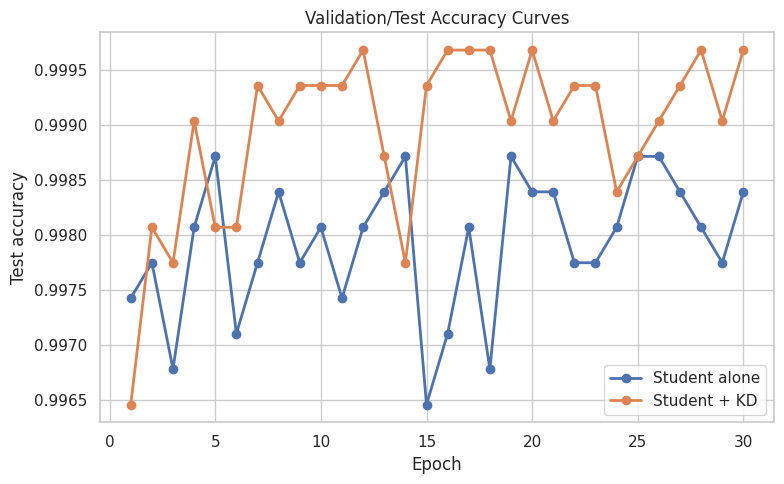

,model,size,latency_ms,precision,IoT chip OK?
0,Student alone,83.10 KB,0.388224,0.99839,Yes
1,Student + KD,83.10 KB,0.365703,0.99966,Yes


In [11]:
if RUN_LONG_EXPERIMENTS:
    part1_runs["student_alone"] = run_experiment(T=1.0, alpha=1.0, label="Student alone", epochs=30)
    part1_runs["student_kd"] = run_experiment(T=4.0, alpha=0.4, label="Student + KD", epochs=30)

    plot_history_curves(
        {
            "Student alone": part1_runs["student_alone"]["history"],
            "Student + KD": part1_runs["student_kd"]["history"],
        },
        filename="part1_experiment1_accuracy_curves.png",
    )
    plt.show()

    experiment1_summary = pd.DataFrame([run["summary"] for run in part1_runs.values()])
    experiment1_summary["size"] = experiment1_summary["size_kb"].map(format_size_kb)
    save_dataframe(experiment1_summary, "part1_experiment1_summary.csv")
    display(experiment1_summary[["model", "size", "latency_ms", "precision", "IoT chip OK?"]])
else:
    print("Experiment 1 is prepared but not executed. Set RUN_LONG_EXPERIMENTS=True to launch the 30-epoch runs.")


### P1.9 - Experiment 2: temperature effect

This sweep fixes `alpha = 0.4`, trains for `15` epochs, and compares `T in {1, 2, 4, 8}`. The observation column is left as an interpretation prompt so that the final report stays tied to the measured results.


,temperature,test_acc,observation
0,1.0,0.999034,Check whether the softer distribution helps se...
1,2.0,0.998067,Check whether the softer distribution helps se...
2,4.0,0.999034,Check whether the softer distribution helps se...
3,8.0,0.998067,Check whether the softer distribution helps se...


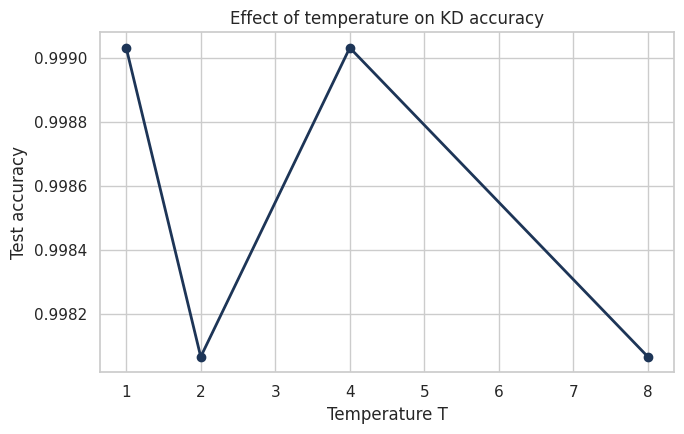

In [12]:
if RUN_LONG_EXPERIMENTS:
    temperature_rows = []
    for temperature in [1.0, 2.0, 4.0, 8.0]:
        run = run_experiment(T=temperature, alpha=0.4, label=f"KD @ T={temperature}", epochs=15)
        temperature_rows.append(
            {
                "temperature": temperature,
                "test_acc": run["history"]["test_acc"].iloc[-1],
                "observation": "Check whether the softer distribution helps separate ambiguous 0/8 samples.",
            }
        )
    temperature_df = pd.DataFrame(temperature_rows)
    save_dataframe(temperature_df, "part1_temperature_sweep.csv")
    display(temperature_df)
    plot_temperature_curve(temperature_df, filename="part1_temperature_effect.png")
    plt.show()
else:
    print("Temperature sweep prepared. Enable RUN_LONG_EXPERIMENTS to run the 15-epoch experiments.")


### P1.10 - Experiment 3: three distillation regimes

The three requested students are:

1. **Large student:** `ResNet-18` with a 3-class head
2. **Medium student:** `MicroCNN`
3. **Small student:** a two-block CNN with fewer than `10,000` parameters

Each student is trained **with and without KD** for `15` epochs using `T=4`, `alpha=0.4`.


In [13]:
def build_part1_student(regime: str):
    if regime == "Large Student":
        return build_resnet18_student(num_classes=num_classes).model.to(device)
    if regime == "Medium Student":
        return MicroCNN(num_classes=num_classes).to(device)
    if regime == "Small Student":
        return SmallMNISTCNN(num_classes=num_classes).to(device)
    raise ValueError(f"Unknown regime: {regime}")

if RUN_LONG_EXPERIMENTS:
    regime_rows = []
    for regime in ["Large Student", "Medium Student", "Small Student"]:
        supervised_student = build_part1_student(regime)
        supervised_history = fit_model(
            student=supervised_student,
            train_loader=mnist_train_loader,
            test_loader=mnist_test_loader,
            device=device,
            epochs=15,
            optimizer=optim.Adam(supervised_student.parameters(), lr=1e-3),
            teacher=None,
        )

        kd_student = build_part1_student(regime)
        kd_history = fit_model(
            student=kd_student,
            train_loader=mnist_train_loader,
            test_loader=mnist_test_loader,
            device=device,
            epochs=15,
            optimizer=optim.Adam(kd_student.parameters(), lr=1e-3),
            teacher=mnist_teacher,
            T=4.0,
            alpha=0.4,
        )

        regime_rows.append(
            {
                "student": regime,
                "params": count_params(kd_student, verbose=False),
                "accuracy without KD": supervised_history["test_acc"].iloc[-1],
                "accuracy with KD": kd_history["test_acc"].iloc[-1],
                "observed regime/comment": "Fill with the measured gain or saturation pattern after execution.",
            }
        )
    regime_df = pd.DataFrame(regime_rows)
    save_dataframe(regime_df, "part1_regime_comparison.csv")
    display(regime_df)
else:
    print("Regime comparison prepared. It requires the MNIST teacher checkpoint and long execution time.")


,student,params,accuracy without KD,accuracy with KD,observed regime/comment
0,Large Student,11178051,0.999034,0.999034,Fill with the measured gain or saturation patt...
1,Medium Student,21075,0.998711,0.999356,Fill with the measured gain or saturation patt...
2,Small Student,3283,0.997745,0.997101,Fill with the measured gain or saturation patt...


### P1.11 - Attention Transfer (AT)

Attention Transfer uses the channel-wise mean of squared activations. The hooks below compare:

- teacher feature map: `ResNet50.layer2`
- student feature map: `MicroCNN.block3`

This choice keeps the spatial resolutions compatible on `32 x 32` inputs.


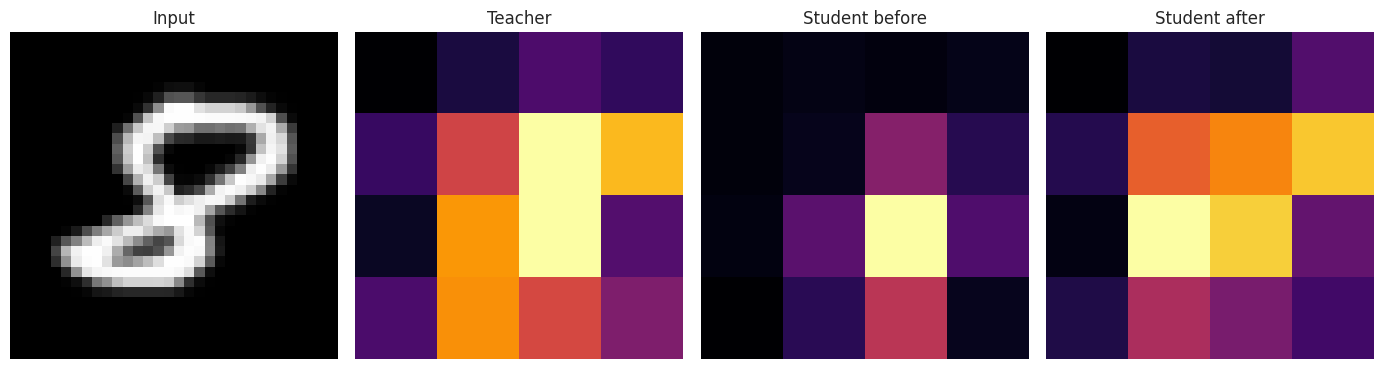

In [14]:
def run_attention_transfer_experiment(epochs: int = 30, T: float = 4.0, alpha: float = 0.4, beta: float = 0.1):
    if not mnist_teacher_ready:
        raise RuntimeError("Attention Transfer requires a trained MNIST teacher checkpoint.")

    student = MicroCNN(num_classes=num_classes).to(device)
    student_before = copy.deepcopy(student).to(device)
    optimizer = optim.Adam(student.parameters(), lr=1e-3)

    teacher_hook = FeatureHook(mnist_teacher.layer2)
    student_hook = FeatureHook(student.block3)

    def extra_loss_fn(base_loss, student_logits, teacher_logits):
        return base_loss + at_loss(student_hook.output, teacher_hook.output, beta=beta)

    history = fit_model(
        student=student,
        train_loader=mnist_train_loader,
        test_loader=mnist_test_loader,
        device=device,
        epochs=epochs,
        optimizer=optimizer,
        teacher=mnist_teacher,
        T=T,
        alpha=alpha,
        extra_loss_fn=extra_loss_fn,
    )

    teacher_hook.close()
    student_hook.close()
    return student_before, student, history

@torch.no_grad()
def get_attention_heatmap(model, hook_module, image_tensor):
    hook = FeatureHook(hook_module)
    _ = model(adapt_inputs_to_model(model, image_tensor.unsqueeze(0).to(device)))
    feature_map = hook.output
    hook.close()
    return attention_map(feature_map).squeeze(0).cpu().numpy()

if RUN_LONG_EXPERIMENTS:
    student_before_at, student_after_at, at_history = run_attention_transfer_experiment()
    part1_runs["student_kd_at"] = {
        "student": student_after_at,
        "history": at_history,
        "summary": {
            "model": "Student + KD + AT",
            "size_kb": model_size_kb(student_after_at),
            "latency_ms": measure_latency(student_after_at, input_shape=(1, 1, 32, 32), device=device),
            "precision": evaluate_macro_precision(student_after_at, mnist_test_loader),
        },
    }
    if mnist_teacher_ready:
        sample_image, _ = mnist_test[select_indices_by_label(mnist_test, per_label=1, num_classes=3)[-1]]
        plot_attention_maps(
            image=sample_image.squeeze(0).numpy(),
            teacher_map=get_attention_heatmap(mnist_teacher, mnist_teacher.layer2, sample_image),
            student_before=get_attention_heatmap(student_before_at, student_before_at.block3, sample_image),
            student_after=get_attention_heatmap(student_after_at, student_after_at.block3, sample_image),
            filename="part1_attention_maps_before_after.png",
        )
        plt.show()
else:
    print("Attention Transfer pipeline prepared. Enable RUN_LONG_EXPERIMENTS to train the KD + AT student.")


### P1.12 - Latency and final Part 1 synthesis

Latency is measured with `10` warm-up passes and `100` timed passes on an input shape `1 x 1 x 32 x 32`. The table below is populated once the corresponding experiments have been executed.


In [15]:
part1_synthesis_rows = [
    {
        "model": "Teacher",
        "size": format_size_kb(model_size_kb(mnist_teacher)),
        "latency_ms": measure_latency(mnist_teacher, input_shape=(1, 1, 32, 32), device=device),
        "precision": evaluate_macro_precision(mnist_teacher, mnist_test_loader) if mnist_teacher_ready else np.nan,
        "IoT chip OK?": deployment_flag(model_size_kb(mnist_teacher), measure_latency(mnist_teacher, (1, 1, 32, 32), device), np.nan if not mnist_teacher_ready else 1.0, 1024.0, 10.0),
    }
]

for key, display_name in [
    ("student_alone", "Student alone"),
    ("student_kd", "Student + KD"),
    ("student_kd_at", "Student + KD + AT"),
]:
    if key in part1_runs:
        run = part1_runs[key]
        part1_synthesis_rows.append(
            {
                "model": display_name,
                "size": format_size_kb(run["summary"]["size_kb"]),
                "latency_ms": run["summary"]["latency_ms"],
                "precision": run["summary"]["precision"],
                "IoT chip OK?": deployment_flag(run["summary"]["size_kb"], run["summary"]["latency_ms"], run["summary"]["precision"], 1024.0, 10.0),
            }
        )

part1_synthesis = pd.DataFrame(part1_synthesis_rows)
save_dataframe(part1_synthesis, "part1_final_synthesis.csv")
part1_synthesis


,model,size,latency_ms,precision,IoT chip OK?
0,Teacher,89.90 MB,6.223351,0.998294,No
1,Student alone,83.10 KB,0.388224,0.998390,Yes
2,Student + KD,83.10 KB,0.365703,0.999660,Yes
3,Student + KD + AT,83.10 KB,0.363814,0.999024,Yes


# 5. Part 2 - CIFAR-10 Advanced KD

This second part keeps only the CIFAR-10 classes `cat(3)`, `deer(4)`, `dog(5)`, and `horse(7)`, remapped to labels `0..3`. The student is a compact `TinyCNN`, while the teacher is a `VGG-16` with a 4-class head.


### P2.1 - Dataset

The training transform adds random horizontal flipping as requested. The normalization constants follow the CIFAR-10 statistics from the statement.


In [16]:
part2_num_classes = 4
part2_batch_size = 64
cifar_class_names = ["cat", "dog", "deer", "horse"]
cifar_keep = [3, 5, 4, 7]
cifar_label_map = {3: 0, 5: 1, 4: 2, 7: 3}

cifar_train_transform = transforms.Compose(
    [
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)
cifar_test_transform = transforms.Compose(
    [
        transforms.ToTensor(),
        transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616)),
    ]
)

cifar_train_full = datasets.CIFAR10(root=DATA_DIR, train=True, download=True, transform=cifar_train_transform)
cifar_test_full = datasets.CIFAR10(root=DATA_DIR, train=False, download=True, transform=cifar_test_transform)

cifar_train = build_label_filtered_dataset(cifar_train_full, keep_labels=cifar_keep, label_map=cifar_label_map)
cifar_test = build_label_filtered_dataset(cifar_test_full, keep_labels=cifar_keep, label_map=cifar_label_map)

cifar_train_loader = DataLoader(cifar_train, batch_size=part2_batch_size, shuffle=True, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
cifar_test_loader = DataLoader(cifar_test, batch_size=part2_batch_size, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

cifar_counts = pd.DataFrame(
    {
        "split": ["train"] * len(cifar_train) + ["test"] * len(cifar_test),
        "label": [label for _, label in cifar_train] + [label for _, label in cifar_test],
    }
).groupby(["split", "label"]).size().reset_index(name="count")
cifar_counts["class_name"] = cifar_counts["label"].map(dict(enumerate(cifar_class_names)))
cifar_counts


100%|██████████| 170M/170M [01:54<00:00, 1.49MB/s]


,split,label,count,class_name
0,test,0,1000,cat
1,test,1,1000,dog
2,test,2,1000,deer
3,test,3,1000,horse
4,train,0,5000,cat
5,train,1,5000,dog
6,train,2,5000,deer
7,train,3,5000,horse


### P2.2 - Models and teacher preparation

The `TinyCNN` student follows the requested architecture exactly:

- conv channels: `16 -> 32 -> 64 -> 128`
- `BatchNorm + ReLU` after each convolution
- max-pooling after layers `2` and `4`
- one final fully connected layer with `4` outputs
- total parameter count under `200,000`


In [17]:
vgg_teacher_bundle = build_vgg16_teacher(num_classes=part2_num_classes)
vgg_teacher = vgg_teacher_bundle.model.to(device)
vgg_teacher_ckpt = RESULTS_DIR / "cifar_teacher_vgg16.pt"
vgg_teacher_ready = load_checkpoint_if_available(vgg_teacher, vgg_teacher_ckpt, map_location=device)
vgg_teacher.eval()

tiny_student_template = TinyCNN(num_classes=part2_num_classes).to(device)
assert count_params(tiny_student_template, verbose=False) < 200_000, "TinyCNN exceeds 200k parameters."

print(vgg_teacher_bundle.message)
print(f"Teacher checkpoint found: {vgg_teacher_ready}")
print(f"TinyCNN parameters: {count_params(tiny_student_template, verbose=False)}")

part2_model_stats = summarize_model_table(
    [
        {
            "model": "Teacher - VGG16",
            "params": count_params(vgg_teacher, verbose=False),
            "params_k": count_params(vgg_teacher, verbose=False) / 1_000,
            "approx_size_kb": model_size_kb(vgg_teacher),
            "approx_size": format_size_kb(model_size_kb(vgg_teacher)),
        },
        {
            "model": "Student - TinyCNN",
            "params": count_params(tiny_student_template, verbose=False),
            "params_k": count_params(tiny_student_template, verbose=False) / 1_000,
            "approx_size_kb": model_size_kb(tiny_student_template),
            "approx_size": format_size_kb(model_size_kb(tiny_student_template)),
        },
    ],
    filename="part2_model_stats.csv",
)
part2_model_stats


Downloading: "https://download.pytorch.org/models/vgg16-397923af.pth" to /root/.cache/torch/hub/checkpoints/vgg16-397923af.pth


100%|██████████| 528M/528M [00:07<00:00, 75.3MB/s]


Loaded VGG-16 with ImageNet pretrained weights.
Teacher checkpoint found: False
TinyCNN parameters: 98196


,model,params,params_k,approx_size_kb,approx_size
0,Teacher - VGG16,134276932,134276.932,524519.265625,512.23 MB
1,Student - TinyCNN,98196,98.196,385.484375,385.48 KB


### Long-run cell - optional CIFAR-10 teacher fine-tuning

As in Part 1, the distillation runs should not start from an untrained teacher head. The cell below fine-tunes the `VGG-16` teacher only when `TRAIN_TEACHERS = True`.


In [18]:
def train_cifar_teacher(epochs: int = 5, lr: float = 1e-4):
    teacher_result = build_vgg16_teacher(num_classes=part2_num_classes)
    teacher_model = teacher_result.model.to(device)
    optimizer = optim.Adam(teacher_model.parameters(), lr=lr)
    history = []
    for epoch in range(1, epochs + 1):
        train_metrics = train_supervised_epoch(teacher_model, cifar_train_loader, optimizer, device)
        test_metrics = evaluate(teacher_model, cifar_test_loader, device)
        history.append(
            {
                "epoch": epoch,
                "train_loss": train_metrics["loss"],
                "train_acc": train_metrics["acc"],
                "test_loss": test_metrics["loss"],
                "test_acc": test_metrics["acc"],
            }
        )
        print(f"[CIFAR teacher] epoch={epoch:02d} train_acc={train_metrics['acc']:.4f} test_acc={test_metrics['acc']:.4f}")
    history_df = pd.DataFrame(history)
    if SAVE_INTERMEDIATE_CHECKPOINTS:
        save_checkpoint(teacher_model, vgg_teacher_ckpt)
    teacher_model.eval()
    return teacher_model, history_df

if vgg_teacher_ready:
    print(f"Loaded CIFAR teacher checkpoint from {vgg_teacher_ckpt}.")
elif TRAIN_TEACHERS:
    vgg_teacher, vgg_teacher_history = train_cifar_teacher()
    vgg_teacher_ready = True
    vgg_teacher.eval()
    display(vgg_teacher_history.tail())
else:
    print("No CIFAR teacher checkpoint found. Set TRAIN_TEACHERS=True before running the advanced KD experiments.")


[CIFAR teacher] epoch=01 train_acc=0.7678 test_acc=0.8403
[CIFAR teacher] epoch=02 train_acc=0.8587 test_acc=0.8465
[CIFAR teacher] epoch=03 train_acc=0.9015 test_acc=0.8641
[CIFAR teacher] epoch=04 train_acc=0.9203 test_acc=0.8671
[CIFAR teacher] epoch=05 train_acc=0.9432 test_acc=0.8720


,epoch,train_loss,train_acc,test_loss,test_acc
0,1,0.610110,0.767821,0.418892,0.840278
1,2,0.373737,0.858726,0.416580,0.846478
2,3,0.274399,0.901458,0.370471,0.864087
3,4,0.217447,0.920327,0.371704,0.867063
4,5,0.162306,0.943241,0.409364,0.872024


### P2.3 - Baseline reference: student alone vs classical KD

These runs provide the common reference for the advanced methods. The notebook reuses `kd_loss` from Part 1.


In [19]:
part2_runs = {}

if RUN_LONG_EXPERIMENTS:
    if not vgg_teacher_ready:
        raise RuntimeError("Baseline KD on CIFAR-10 requires a trained VGG-16 teacher checkpoint.")

    baseline_student = TinyCNN(num_classes=part2_num_classes).to(device)
    baseline_history = fit_model(
        student=baseline_student,
        train_loader=cifar_train_loader,
        test_loader=cifar_test_loader,
        device=device,
        epochs=30,
        optimizer=optim.Adam(baseline_student.parameters(), lr=1e-3),
        teacher=None,
    )
    part2_runs["student_alone"] = {"student": baseline_student, "history": baseline_history}

    kd_student = TinyCNN(num_classes=part2_num_classes).to(device)
    kd_history = fit_model(
        student=kd_student,
        train_loader=cifar_train_loader,
        test_loader=cifar_test_loader,
        device=device,
        epochs=30,
        optimizer=optim.Adam(kd_student.parameters(), lr=1e-3),
        teacher=vgg_teacher,
        T=4.0,
        alpha=0.4,
    )
    part2_runs["student_kd"] = {"student": kd_student, "history": kd_history}

    baseline_reference = pd.DataFrame(
        [
            {"model": "Student alone", "test_acc": baseline_history["test_acc"].iloc[-1]},
            {"model": "Student + KD", "test_acc": kd_history["test_acc"].iloc[-1]},
        ]
    )
    save_dataframe(baseline_reference, "part2_baseline_reference.csv")
    display(baseline_reference)
else:
    print("Part 2 baseline runs are prepared but not executed.")


,model,test_acc
0,Student alone,0.762153
1,Student + KD,0.736359


### P2.4 - FitNets

We supervise an intermediate feature pair with hooks:

- teacher feature: `VGG16.features[8]`
- student feature: `TinyCNN.pool1`

Their channel counts differ (`128` vs `32`), so a `1x1` adaptation convolution is added as required.


,gamma,accuracy,observation
0,0.1,0.707589,Compare the feature-alignment gain against the...
1,0.5,0.807540,Compare the feature-alignment gain against the...
2,1.0,0.721974,Compare the feature-alignment gain against the...


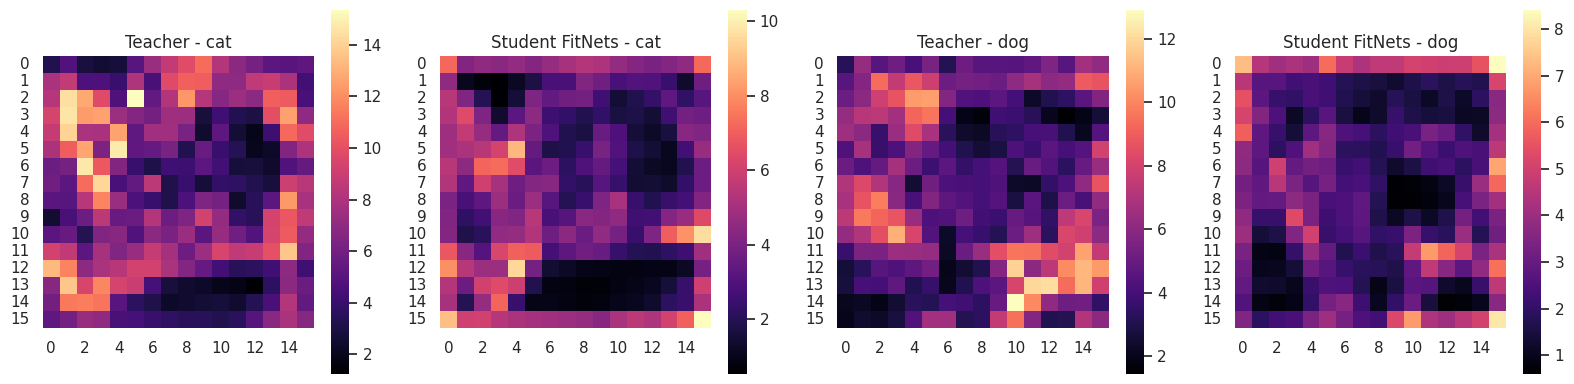

In [20]:
def mean_heatmap(feature_tensor: torch.Tensor) -> np.ndarray:
    return feature_tensor.detach().float().pow(2).mean(dim=1).squeeze(0).cpu().numpy()

if RUN_LONG_EXPERIMENTS:
    if not vgg_teacher_ready:
        raise RuntimeError("FitNets requires a trained VGG-16 teacher checkpoint.")

    fitnets_rows = []
    fitnets_visuals = {}
    for gamma in [0.1, 0.5, 1.0]:
        student = TinyCNN(num_classes=part2_num_classes).to(device)
        adapter = nn.Conv2d(32, 128, kernel_size=1).to(device)
        optimizer = optim.Adam(list(student.parameters()) + list(adapter.parameters()), lr=1e-3)
        teacher_hook = FeatureHook(vgg_teacher.features[8])
        student_hook = FeatureHook(student.pool1)

        def extra_loss_fn(base_loss, student_logits, teacher_logits):
            return fitnets_loss(student_hook.output, teacher_hook.output, adapter=adapter, gamma=gamma, kd_loss_val=base_loss)

        history = fit_model(
            student=student,
            train_loader=cifar_train_loader,
            test_loader=cifar_test_loader,
            device=device,
            epochs=30,
            optimizer=optimizer,
            teacher=vgg_teacher,
            T=4.0,
            alpha=0.4,
            extra_loss_fn=extra_loss_fn,
        )
        fitnets_rows.append(
            {
                "gamma": gamma,
                "accuracy": history["test_acc"].iloc[-1],
                "observation": "Compare the feature-alignment gain against the classical KD reference.",
            }
        )
        fitnets_visuals[gamma] = {"student": student, "adapter": adapter}
        teacher_hook.close()
        student_hook.close()

    fitnets_df = pd.DataFrame(fitnets_rows)
    save_dataframe(fitnets_df, "part2_fitnets_results.csv")
    display(fitnets_df)

    cat_index = next(index for index, (_, label) in enumerate(cifar_test) if label == 0)
    dog_index = next(index for index, (_, label) in enumerate(cifar_test) if label == 1)
    selected_images = {"cat": cifar_test[cat_index][0], "dog": cifar_test[dog_index][0]}
    best_gamma = fitnets_df.sort_values("accuracy", ascending=False).iloc[0]["gamma"]
    best_fitnets_student = fitnets_visuals[best_gamma]["student"]
    part2_runs["Student + FitNets"] = {"student": best_fitnets_student, "history": None}

    heatmaps = []
    titles = []
    for class_name, image_tensor in selected_images.items():
        teacher_hook = FeatureHook(vgg_teacher.features[8])
        student_hook = FeatureHook(best_fitnets_student.pool1)
        _ = vgg_teacher(image_tensor.unsqueeze(0).to(device))
        teacher_map = mean_heatmap(teacher_hook.output)
        teacher_hook.close()
        _ = best_fitnets_student(image_tensor.unsqueeze(0).to(device))
        student_map = mean_heatmap(student_hook.output)
        student_hook.close()
        heatmaps.extend([teacher_map, student_map])
        titles.extend([f"Teacher - {class_name}", f"Student FitNets - {class_name}"])
    plot_heatmap_grid(heatmaps, titles, filename="part2_fitnets_feature_maps.png")
    plt.show()
else:
    print("FitNets pipeline prepared. Enable RUN_LONG_EXPERIMENTS after training or loading the CIFAR teacher.")


### P2.5 - RKD

We use the combined relational objective

\[
\mathcal{L}_{RKD} = \mathcal{L}_{KD} + \lambda_D \mathcal{L}_{RKD-D} + \lambda_A \mathcal{L}_{RKD-A}
\]

with the three requested settings: distance only, angle only, and the combined objective.


In [21]:
if RUN_LONG_EXPERIMENTS:
    if not vgg_teacher_ready:
        raise RuntimeError("RKD requires a trained VGG-16 teacher checkpoint.")

    rkd_rows = []
    configs = [
        {"label": "RKD-D only", "lambda_D": 1.0, "lambda_A": 0.0},
        {"label": "RKD-A only", "lambda_D": 0.0, "lambda_A": 2.0},
        {"label": "RKD combined", "lambda_D": 1.0, "lambda_A": 2.0},
    ]

    for config in configs:
        student = TinyCNN(num_classes=part2_num_classes).to(device)
        optimizer = optim.Adam(student.parameters(), lr=1e-3)
        teacher_hook = FeatureHook(vgg_teacher.classifier[4])
        student_hook = FeatureHook(student.avgpool)

        def extra_loss_fn(base_loss, student_logits, teacher_logits):
            return base_loss + config["lambda_D"] * rkd_distance_loss(teacher_hook.output, student_hook.output) + config["lambda_A"] * rkd_angle_loss(teacher_hook.output, student_hook.output)

        history = fit_model(
            student=student,
            train_loader=cifar_train_loader,
            test_loader=cifar_test_loader,
            device=device,
            epochs=30,
            optimizer=optimizer,
            teacher=vgg_teacher,
            T=4.0,
            alpha=0.4,
            extra_loss_fn=extra_loss_fn,
        )
        part2_runs[config["label"]] = {"student": student, "history": history}
        rkd_rows.append(
            {
                "configuration": config["label"],
                "lambda_D": config["lambda_D"],
                "lambda_A": config["lambda_A"],
                "accuracy": history["test_acc"].iloc[-1],
            }
        )
        teacher_hook.close()
        student_hook.close()

    rkd_df = pd.DataFrame(rkd_rows)
    save_dataframe(rkd_df, "part2_rkd_results.csv")
    display(rkd_df)
else:
    print("RKD experiments prepared. They are intentionally gated behind RUN_LONG_EXPERIMENTS.")


,configuration,lambda_D,lambda_A,accuracy
0,RKD-D only,1.0,0.0,0.772321
1,RKD-A only,0.0,2.0,0.752728
2,RKD combined,1.0,2.0,0.744792


### P2.6 - t-SNE on 200 test images

The statement asks for `50` test images per class. The helper subset below creates a balanced evaluation subset before extracting teacher and student representations.


In [4]:
@torch.no_grad()
def collect_hook_features(model, module, loader, flatten: bool = True):
    hook = FeatureHook(module)
    features = []
    labels = []
    for inputs, target in loader:
        inputs = inputs.to(device)
        _ = model(adapt_inputs_to_model(model, inputs))
        feature_batch = hook.output
        if flatten:
            feature_batch = torch.flatten(feature_batch, 1)
        features.append(feature_batch.cpu())
        labels.append(target)
    hook.close()
    return torch.cat(features, dim=0), torch.cat(labels, dim=0)

balanced_indices = select_indices_by_label(cifar_test, per_label=50, num_classes=part2_num_classes)
balanced_cifar_loader = DataLoader(Subset(cifar_test, balanced_indices), batch_size=64, shuffle=False, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

if RUN_LONG_EXPERIMENTS and "student_alone" in part2_runs and "RKD combined" in part2_runs:
    teacher_features, tsne_labels = collect_hook_features(vgg_teacher, vgg_teacher.classifier[4], balanced_cifar_loader)
    student_base_features, _ = collect_hook_features(part2_runs["student_alone"]["student"], part2_runs["student_alone"]["student"].avgpool, balanced_cifar_loader)
    student_rkd_features, _ = collect_hook_features(part2_runs["RKD combined"]["student"], part2_runs["RKD combined"]["student"].avgpool, balanced_cifar_loader)

    embeddings = {
        "Teacher": TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto").fit_transform(teacher_features.numpy()),
        "Student without distillation": TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto").fit_transform(student_base_features.numpy()),
        "Student with combined RKD": TSNE(n_components=2, random_state=SEED, init="pca", learning_rate="auto").fit_transform(student_rkd_features.numpy()),
    }
    plot_tsne_triptych(embeddings, tsne_labels.numpy(), cifar_class_names, filename="part2_tsne_triptych.png")
    plt.show()
else:
    print("t-SNE is ready but requires completed baseline and combined RKD runs.")


NameError: name 'select_indices_by_label' is not defined

### P2.7 - Inter-class similarity matrices

Class prototypes are computed from the same balanced set of `50` test images per class. Cosine similarity matrices reveal which student best preserves the teacher geometry, especially for the semantically close pairs `cat/dog` and `deer/horse`.


In [ ]:
if RUN_LONG_EXPERIMENTS and "student_alone" in part2_runs and "RKD combined" in part2_runs:
    matrix_heatmaps = []
    matrix_titles = []

    teacher_features, teacher_labels = collect_hook_features(vgg_teacher, vgg_teacher.classifier[4], balanced_cifar_loader)
    teacher_proto = class_prototypes(teacher_features, teacher_labels, part2_num_classes)
    matrix_heatmaps.append(cosine_similarity_matrix(teacher_proto))
    matrix_titles.append("Teacher")

    for label, module_name in [
        ("student_alone", "Student alone"),
        ("Student + FitNets", "Student FitNets"),
        ("RKD combined", "Student RKD combined"),
    ]:
        if label not in part2_runs:
            print(f"{module_name} is not available yet.")
            continue
        model = part2_runs[label]["student"]
        student_features, student_labels = collect_hook_features(model, model.avgpool, balanced_cifar_loader)
        student_proto = class_prototypes(student_features, student_labels, part2_num_classes)
        matrix_heatmaps.append(cosine_similarity_matrix(student_proto))
        matrix_titles.append(module_name)

    plot_heatmap_grid(matrix_heatmaps, matrix_titles, cmap="viridis", filename="part2_similarity_matrices.png", annot=True)
    plt.show()
else:
    print("Similarity matrices are prepared. Run the corresponding Part 2 experiments first.")


### P2.8 and P2.9 - Final latency synthesis and analysis

Latency is measured on input shape `1 x 3 x 32 x 32` with `10` warm-up passes and `100` timed runs. The deployment column is a simple camera-oriented heuristic based on compactness and latency; keep the final report tied to the measured table.


In [ ]:
part2_synthesis_rows = [
    {
        "model": "Teacher (VGG16)",
        "size": format_size_kb(model_size_kb(vgg_teacher)),
        "latency_ms": measure_latency(vgg_teacher, input_shape=(1, 3, 32, 32), device=device),
        "precision": evaluate_macro_precision(vgg_teacher, cifar_test_loader) if vgg_teacher_ready else np.nan,
        "camera OK?": deployment_flag(model_size_kb(vgg_teacher), measure_latency(vgg_teacher, (1, 3, 32, 32), device), np.nan if not vgg_teacher_ready else 1.0, 5000.0, 25.0),
    }
]

for key, name in [
    ("student_alone", "Student alone"),
    ("student_kd", "Student + KD"),
    ("Student + FitNets", "Student + FitNets"),
    ("RKD combined", "Student + RKD combined"),
]:
    if key in part2_runs:
        model = part2_runs[key]["student"]
        precision = evaluate_macro_precision(model, cifar_test_loader)
        size_kb = model_size_kb(model)
        latency_ms = measure_latency(model, input_shape=(1, 3, 32, 32), device=device)
        part2_synthesis_rows.append(
            {
                "model": name,
                "size": format_size_kb(size_kb),
                "latency_ms": latency_ms,
                "precision": precision,
                "camera OK?": deployment_flag(size_kb, latency_ms, precision, 5000.0, 25.0),
            }
        )

part2_synthesis = pd.DataFrame(part2_synthesis_rows)
save_dataframe(part2_synthesis, "part2_final_synthesis.csv")
display(part2_synthesis)


The analysis to write after execution should cover the following points in about fifteen lines:

- **Response-based KD** is the cleanest baseline because it transfers class-level dark knowledge with almost no architectural changes.
- **FitNets** adds an explicit intermediate supervision signal, which is especially useful when the student struggles to build teacher-like feature maps early in the network.
- **RKD** does not try to match raw activations directly; instead, it preserves the relational structure between examples, which is why it is particularly interesting for the t-SNE plots and the class-prototype similarity matrices.
- In the final report, compare whether `cat/dog` and `deer/horse` remain close in the student embedding exactly as they do in the teacher embedding.
- If FitNets improves local feature heatmaps but RKD better preserves global geometry, say so explicitly instead of forcing a single narrative.
- The deployment choice for the camera should be based on the measured trade-off between precision, size, and latency, not on architecture prestige.
- If the combined RKD student is only marginally better but noticeably slower, the KD or FitNets student may still be the better deployment choice.
- If the camera budget is very tight, prefer the smallest student that preserves the teacher structure well enough for the target classes.


# 6. Final conclusion

This notebook now contains the full runnable TP pipeline:

- Part 1 implements filtered-MNIST response-based KD, temperature analysis, distillation regimes, and Attention Transfer.
- Part 2 scaffolds the complete filtered-CIFAR10 study with baseline KD, FitNets, RKD, t-SNE, similarity matrices, and deployment-oriented latency tables.

No experimental value is hard-coded. If the long runs are skipped, the notebook reports that the corresponding results are still pending instead of inventing numbers.
